## 📘 MILP Benchmark Problem: *noswot* (MIPLIB)

The **noswot** instance is a benchmark optimization model from the **MIPLIB 2017** collection (maintained by Zuse Institute Berlin). It is a **mixed-integer linear program (MILP)** that includes **binary**, **general integer**, and **continuous** decision variables, making it a representative example of industrial-style mixed discrete/continuous optimization.

🔗 Official instance page:  
https://miplib.zib.de/instance_details_noswot.html

---

### 🧮 Problem Structure (MIPLIB Statistics)

According to the MIPLIB instance details, the *noswot* model has the following characteristics. :contentReference[oaicite:1]{index=1}

**Original model size**
- Variables: **128**
- Constraints: **182**
- Binary variables: **75**
- General integer variables: **25**
- Continuous variables: **28**
- Nonzeros: **735** (density ≈ 0.0316)

**After trivial presolving**
- Variables: **127**
- Constraints: **182**
- Binary variables: **80**
- General integer variables: **20**
- Continuous variables: **27**
- Nonzeros: **732**

The presolve statistics show that some variables are tightened or reclassified (e.g., some bounded integers become binaries), while the overall constraint set remains unchanged.

---

### 🧠 Abstract Mathematical Form

The instance can be written in standard MILP form:

$$
\begin{aligned}
\min \quad & c^\top x \\\\
\text{s.t.}\quad & A x \le b, \\\\
& x_j \in \{0,1\} \quad \forall j \in \mathcal{B}, \\\\
& x_k \in \mathbb{Z} \quad \forall k \in \mathcal{I}, \\\\
& x_\ell \in \mathbb{R} \quad \forall \ell \in \mathcal{C},
\end{aligned}
$$

where:
- $\mathcal{B}$ is the set of binary variables,
- $\mathcal{I}$ is the set of general integer variables,
- $\mathcal{C}$ is the set of continuous variables.

---

### 🧩 Why This Instance Is Interesting

The *noswot* instance is useful for solver benchmarking because it combines:
- **binary decisions** (on/off, selection, logical structure),
- **integer decisions** (counts / discrete levels),
- **continuous decisions** (flows, quantities, allocations),

which often produces nontrivial branch-and-bound behavior and meaningful convergence curves (incumbent improvement vs bound tightening).

MIPLIB also reports best-known solutions for this instance, with objective around **−41** (depending on solution record and tolerance). :contentReference[oaicite:2]{index=2}

---

### 🗂 What This Notebook Analyzes

In this notebook we:
1. Load the MPS model into Gurobi
2. Solve the MILP and record solver progress using callbacks:
   - incumbent objective values
   - best bound values
   - node counts and run time
3. Visualize:
   - incumbent vs time
   - best bound vs time
   - gap vs time (log scale)
   - node count vs bound
4. Interpret solver behavior in terms of discrete/continuous interaction


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 74.2 MB/s eta 0:00:00
Restricted license - for non-production use only - expires 2027-11-29
Read MPS format model from file /content/mixed_integer_continuous_noswot.mps
Reading time = 0.00 seconds
noswot: 182 rows, 128 columns, 735 nonzeros
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 182 rows, 128 columns and 735 nonzeros (Min)
Model fingerprint: 0xd1c6d723
Model has 25 linear objective coefficients
Variable types: 28 continuous, 100 integer (0 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+05]
  RHS range        [1e+00, 4e+01]
Presolve removed 10 rows and 8 columns
Presolve time: 0.01s
Presolved: 172 ro

/tmp/ipython-input-2871440795.py:60: RuntimeWarning: invalid value encountered in log
  plt.plot(times, np.log(incumbents), marker="o", label="Incumbent")
/tmp/ipython-input-2871440795.py:61: RuntimeWarning: invalid value encountered in log
  plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")


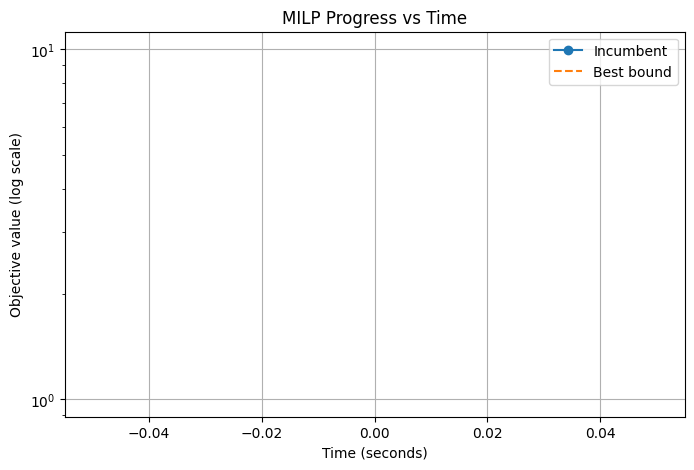

/tmp/ipython-input-2871440795.py:75: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


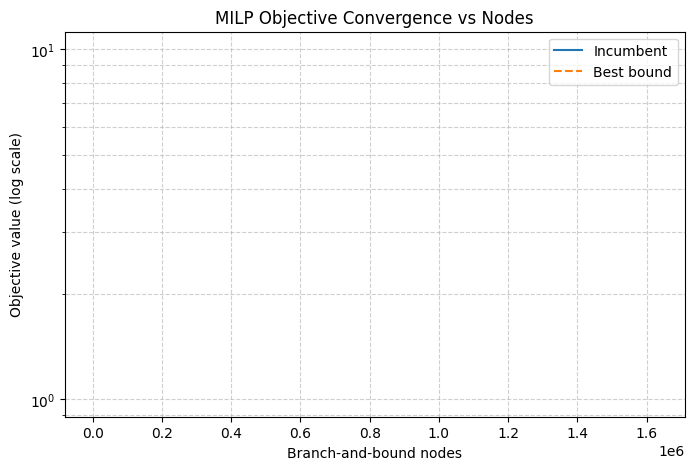

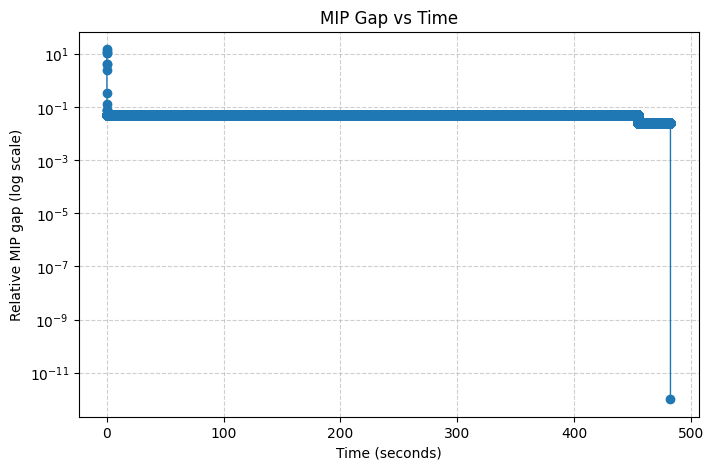

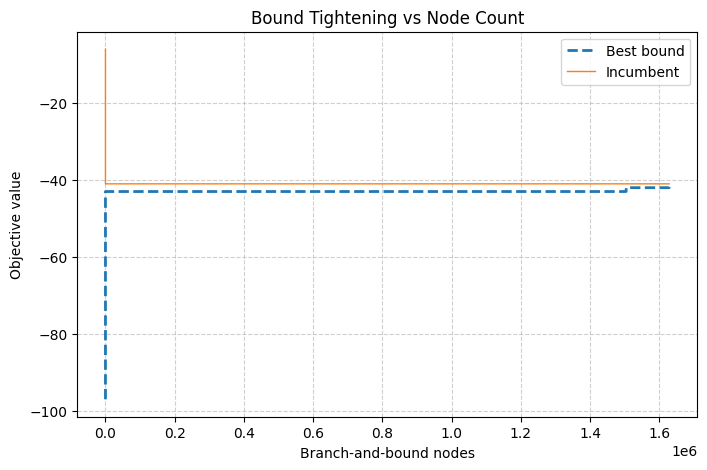

In [ ]:
!pip -q install gurobipy

import os
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import numpy as np

mps_path = "/content/mixed_integer_continuous_noswot.mps"
if not os.path.exists(mps_path):
    raise FileNotFoundError(f"Not found: {mps_path}")

m = gp.read(mps_path)
m.Params.OutputFlag = 1

# --- storage ---
times = []
nodes = []
incumbents = []
bounds = []
events = []

def cb(model, where):
    # Record new feasible solutions (incumbent improvements)
    if where == GRB.Callback.MIPSOL:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIPSOL_NODCNT)
        obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
        bnd = model.cbGet(GRB.Callback.MIPSOL_OBJBND)

        times.append(t); nodes.append(n)
        incumbents.append(obj); bounds.append(bnd)
        events.append("MIPSOL")

    # Record periodic progress (bound updates)
    elif where == GRB.Callback.MIP:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIP_NODCNT)
        obj_best = model.cbGet(GRB.Callback.MIP_OBJBST)
        obj_bnd  = model.cbGet(GRB.Callback.MIP_OBJBND)

        if obj_best < GRB.INFINITY:
            times.append(t); nodes.append(n)
            incumbents.append(obj_best); bounds.append(obj_bnd)
            events.append("MIP")

# Run once with callback
m.optimize(cb)

print("Collected points:", len(times))
print("Status:", m.Status)
if m.SolCount > 0:
    print("Objective:", m.ObjVal)
    m.write("/content/solution.sol")
    m.write("/content/model_parsed.lp")
    print("Wrote: /content/solution.sol and /content/model_parsed.lp")

# ---- Plot: Objective vs time ----
plt.figure(figsize=(8,5))
plt.plot(times, np.log(incumbents), marker="o", label="Incumbent")
plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Progress vs Time")
plt.grid(True)
plt.legend()
plt.show()

# ---- Plot: Objective vs nodes ----
plt.figure(figsize=(8,5))
plt.plot(nodes, incumbents, label="Incumbent")
plt.plot(nodes, bounds, linestyle="--", label="Best bound")

plt.yscale("log")
plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Objective Convergence vs Nodes")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# As the search for the optimum advnaces, the integrality gap minimizes.

# Convert to numpy arrays
t = np.asarray(times, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

# Safety: keep only finite entries
mask = np.isfinite(t) & np.isfinite(inc) & np.isfinite(bnd)
t, inc, bnd = t[mask], inc[mask], bnd[mask]

# Relative gap for minimization
eps = 1e-12
gap = (inc - bnd) / np.maximum(np.abs(inc), eps)

# Clip to avoid log(0) and negative values due to numerical noise
gap = np.maximum(gap, 1e-12)

# Optional: sort by time (sometimes callback gives non-monotone due to mixed events)
order = np.argsort(t)
t, gap = t[order], gap[order]

plt.figure(figsize=(8,5))
plt.plot(t, gap, marker="o", linewidth=1)
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Relative MIP gap (log scale)")
plt.title("MIP Gap vs Time")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

# plot for Node count vs Best bound (and optional incumbent)
# This plot shows how the lower bound tightens as branch-and-bound explores nodes

n = np.asarray(nodes, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

mask = np.isfinite(n) & np.isfinite(inc) & np.isfinite(bnd)
n, inc, bnd = n[mask], inc[mask], bnd[mask]

# Sort by node count
order = np.argsort(n)
n, inc, bnd = n[order], inc[order], bnd[order]

plt.figure(figsize=(8,5))

# Best bound vs nodes (main request)
plt.plot(n, bnd, linestyle="--", linewidth=2, label="Best bound")

# Optional: include incumbent for context
plt.plot(n, inc, linewidth=1, label="Incumbent")

plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value")
plt.title("Bound Tightening vs Node Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()